# Oving 3 INFT2003 - Pandas og Dataanalyse

In [12]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

### Oppgave 1

In [13]:
df = pd.read_csv('H1.csv')

# Grupperer alle landene og teller alle hendelsene
country_counts = df.groupby('Country')['Country'].count()

# Viser de 10 landene med flest kunder
top_10_countries = country_counts.nlargest(10)

top_10_countries

Country
PRT    17630
GBR     6814
ESP     3957
IRL     2166
FRA     1611
DEU     1203
CN       710
NLD      514
USA      479
ITA      459
Name: Country, dtype: int64

### Oppgave 2

In [14]:
df = pd.read_csv('H1.csv')

# Filterer bort rader hvor bookings er kansellert
df_not_canceled = df[df['IsCanceled'] == 0]

# Oppretter en ny kolonne for pris. (Antar at ADR (Average Daily Rate) skal ganges med summen av netter i helg og ukedager)
df_not_canceled.loc[:, 'TotalRevenue'] = df_not_canceled['ADR'] * (df_not_canceled['StaysInWeekendNights'] + df_not_canceled['StaysInWeekNights'])

# Grupperer etter MarketSegment og velger sum av den nye pris-kolonnen
revenue_by_segment = df_not_canceled.groupby('MarketSegment')['TotalRevenue'].sum()

revenue_by_segment

C:\Users\Jens\AppData\Local\Temp\ipykernel_22888\1546350202.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_not_canceled.loc[:, 'TotalRevenue'] = df_not_canceled['ADR'] * (df_not_canceled['StaysInWeekendNights'] + df_not_canceled['StaysInWeekNights'])


MarketSegment
Complementary       2069.53
Corporate         212236.79
Direct           2441868.50
Groups            888304.26
Offline TA/TO    3105513.25
Online TA        4951857.90
Name: TotalRevenue, dtype: float64

### Oppgave 3

-6.38 508.0


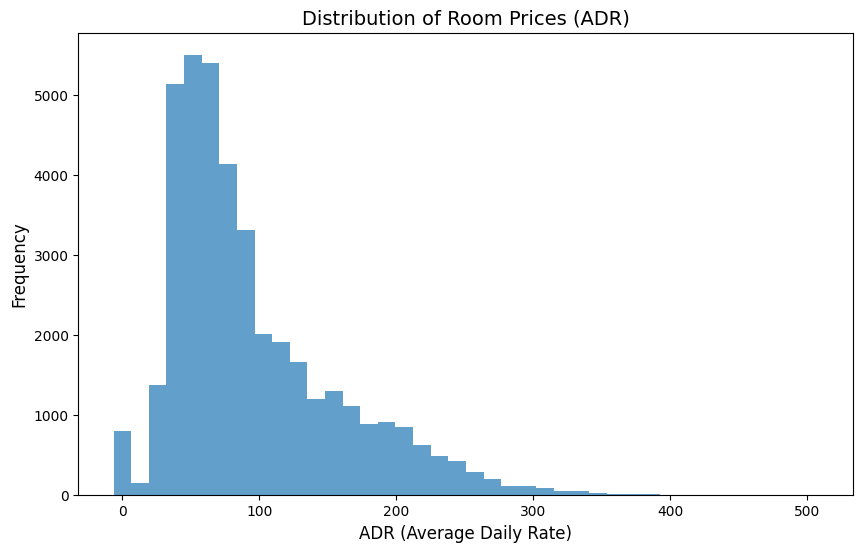

In [17]:
df = pd.read_csv('H1.csv')

# Finner start og slutt verdiene for intervallet
max_adr = df['ADR'].max()
min_adr = df['ADR'].min()
print(min_adr, max_adr)

# Velger størrelse og forhold 10:6, med 40 bins og gjennomsiktlighet 0.7
plt.figure(figsize=(10, 6))
plt.hist(df['ADR'], bins=40, range=(min_adr, max_adr), alpha=0.7)

# Tittel og label etc.
plt.title('Distribution of Room Prices (ADR)', fontsize=14)
plt.xlabel('ADR (Average Daily Rate)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

### Oppgave 4

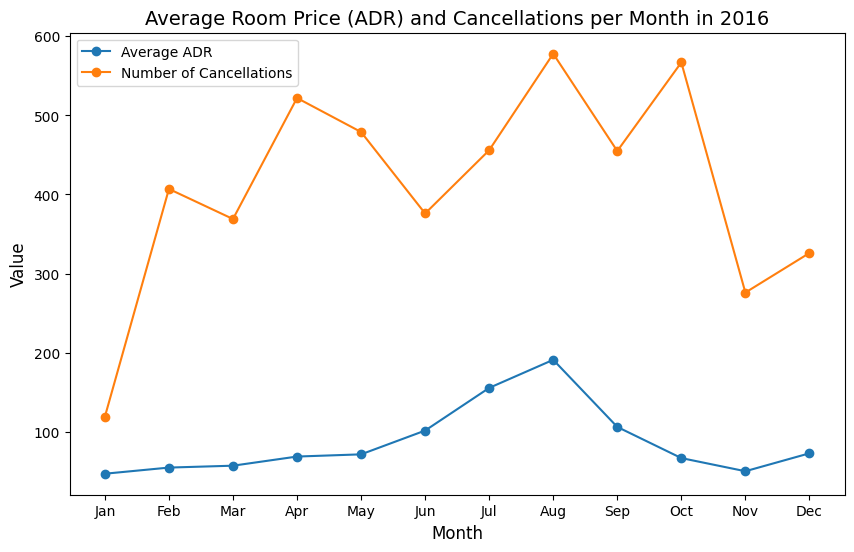

In [16]:
df = pd.read_csv('H1.csv')

# Filterer bort data som ikke er i 2016
df_2016 = df[df['ArrivalDateYear'] == 2016]

# Konverter månedsnavn til en numerisk verdi (1-12) for å plotte månedene kronologisk
df_2016.loc[:, 'ArrivalDateMonth'] = pd.to_datetime(df_2016['ArrivalDateMonth'], format='%B').dt.month

# Beregner gjennom snitt av AVD for hver måned
monthly_avg_adr = df_2016.groupby('ArrivalDateMonth')['ADR'].mean()

# Teller hendelser av kanselleringer for hver måned
monthly_cancellations = df_2016[df_2016['IsCanceled'] == 1].groupby('ArrivalDateMonth')['IsCanceled'].count()

# Plotter linjediagrammene i samme figur
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg_adr.index, monthly_avg_adr.values, label='Average ADR', marker='o')
plt.plot(monthly_cancellations.index, monthly_cancellations.values, label='Number of Cancellations', marker='o')
plt.title('Average Room Price (ADR) and Cancellations per Month in 2016', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend()

# Setter navn igjen på månedene på x-aksen
plt.xticks(ticks=monthly_avg_adr.index, labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.show()